In [1]:
library(Seurat)
library(immunarch)
library(dplyr)
library(ggalluvial)
library(tidyr)
library(scRepertoire)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Loading required package: dplyr

Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: dtplyr

Loading required package: data.table

Warning message:
“package ‘data.table’ was built under R version 4.4.3”

Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


Loading required package: patchwork

Warning message:
“package ‘patchwork’ was built under R version 4.4.3”


In [2]:
so <- readRDS('manuscript/VST2_Processing/vst2_t_cells.rds')
so

An object of class Seurat 
18168 features across 647032 samples within 2 assays 
Active assay: RNA (18129 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 1 other assay present: escape.ssGSEA
 2 dimensional reductions calculated: pca, umap

# Clean up TCR data for TREX

In [3]:
library(stringr)

Warning message:
“package ‘stringr’ was built under R version 4.4.3”


In [4]:
meta <- so@meta.data %>%
  mutate(
    TRAV = str_extract(CTgene, "TRAV[^*]*"),
    TRAJ = str_extract(CTgene, "TRAJ[^*]*"),
    TRAC = str_extract(CTgene, "TRAC[^*]*"),
    TRBV = str_extract(CTgene, "TRBV[^*]*"),
    TRBJ = str_extract(CTgene, "TRBJ[^*]*"),
    TRBC = str_extract(CTgene, "TRBC[^*]*")
  )
head(meta)

,orig.ident,nCount_RNA,nFeature_RNA,barcodes,AIFI_PBMC.Flex_L1,AIFI_PBMC.Flex_L2,AIFI_PBMC.Flex_L3,batch_id,cell_name,cell_uuid,⋯,Culture_Peptide,RNA_snn_res.0.8,seurat_clusters,pep_enriched,TRAV,TRAJ,TRAC,TRBV,TRBJ,TRBC
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<fct>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1de16aa05c2011f0a76a2e8167d1be4d,SeuratProject,29867,6645,1de16aa05c2011f0a76a2e8167d1be4d,T cell,Proliferating T cell,Proliferating T cell,EXP-01589-PC,vegetal_sphingine_krill,1de16aa05c2011f0a76a2e8167d1be4d,⋯,IL7_IL15_Pep_neg,19,19,Non-Activated,TRAV38-1,TRAJ21,TRAC,TRBV28,TRBJ2-7,TRBC2
1de16b545c2011f0a76a2e8167d1be4d,SeuratProject,949,758,1de16b545c2011f0a76a2e8167d1be4d,T cell,Treg,Memory CD4 Treg,EXP-01589-PC,carbonous_improved_xerus,1de16b545c2011f0a76a2e8167d1be4d,⋯,IL7_IL15_Pep_neg,21,21,Non-Activated,NA,NA,NA,NA,NA,NA
1de16c625c2011f0a76a2e8167d1be4d,SeuratProject,1650,1217,1de16c625c2011f0a76a2e8167d1be4d,T cell,Memory CD4 T cell,CM CD4 T cell,EXP-01589-PC,unrelative_heathenish_koalabear,1de16c625c2011f0a76a2e8167d1be4d,⋯,IL7_IL15_Pep_neg,21,21,Non-Activated,TRAV4,TRAJ3,TRAC,TRBV3-1,TRBJ2-5,TRBC2
1de16d5c5c2011f0a76a2e8167d1be4d,SeuratProject,1831,1279,1de16d5c5c2011f0a76a2e8167d1be4d,T cell,Memory CD8 T cell,ISG+ memory CD4 T cell,EXP-01589-PC,cold_greenish_chrysalis,1de16d5c5c2011f0a76a2e8167d1be4d,⋯,IL7_IL15_Pep_neg,0,0,Non-Activated,NA,NA,NA,TRBV24-1,TRBJ2-2,TRBC2
1de16dde5c2011f0a76a2e8167d1be4d,SeuratProject,1651,1146,1de16dde5c2011f0a76a2e8167d1be4d,T cell,Naive CD4 T cell,ISG+ naive CD4 T cell,EXP-01589-PC,landpoor_loving_wallaroo,1de16dde5c2011f0a76a2e8167d1be4d,⋯,IL7_IL15_Pep_neg,0,0,Non-Activated,TRAV26-1,TRAJ49,TRAC,TRBV3-1,TRBJ2-3,TRBC2
1de16e565c2011f0a76a2e8167d1be4d,SeuratProject,3839,2306,1de16e565c2011f0a76a2e8167d1be4d,T cell,gdT,Adaptive NK cell,EXP-01589-PC,censorable_detestable_fox,1de16e565c2011f0a76a2e8167d1be4d,⋯,IL7_IL15_Pep_neg,7,7,Non-Activated,NA,NA,NA,NA,NA,NA


In [5]:
so$CTgene_archive <- so$CTgene

In [6]:
so$CTgene <- paste0(meta$TRAV,'.',meta$TRAJ,'.',meta$TRAC,'_',meta$TRBV,'.',meta$TRBJ,'.',meta$TRBC)

In [7]:
so$CTaa_TRA <- stringr::str_split_i(string = so$CTaa, pattern = '_', i = 1)
so$CTaa_TRB <- stringr::str_split_i(string = so$CTaa, pattern = '_', i = 2)

In [8]:
so$CDR3a <- stringr::str_split_i(string = so$CTaa_TRA, pattern = ';', i = 1)
so$CTaa_TRA_2 <- stringr::str_split_i(string = so$CTaa_TRA, pattern = ';', i = 2)
so$CDR3b <- stringr::str_split_i(string = so$CTaa_TRB, pattern = ';', i = 1)
so$CTaa_TRB_2 <- stringr::str_split_i(string = so$CTaa_TRB, pattern = ';', i = 2)

In [9]:
so$CTaa_archive <- so$CTaa

In [10]:
so$CTaa <- paste(so$CDR3a,so$CDR3b,sep='_')

In [11]:
table(so$sample_id)


FIX08836-004 FIX08836-005 FIX08836-006 FIX08836-007 FIX08836-008 FIX08836-009 
       10282        11102         9075         9921        10000        12005 
FIX08836-010 FIX08836-011 FIX08836-012 FIX08836-013 FIX08836-014 FIX08836-015 
       10581        16141        12328        11785         9341        12050 
FIX08836-016 FIX08836-017 FIX08836-018 FIX10434-001 FIX10434-002 FIX10434-003 
       13506        12657        15264        11861        17627         9694 
FIX10434-004 FIX10434-005 FIX10434-006 FIX10434-007 FIX10434-008 FIX10434-009 
       14088        12675        12873        12092        12123        15768 
FIX10434-010 FIX10434-011 FIX10434-012 FIX10434-013 FIX10434-014 FIX10434-015 
       13995        16275        21605        21871        20202        18960 
FIX10435-001 FIX10435-002 FIX10435-003 FIX10435-004 FIX10435-005 FIX10435-006 
       15984        15087        11578        15506        15511        15309 
FIX10435-007 FIX10435-008 FIX10435-009 FIX10435-010

# Annotate via VDJdb

In [12]:
vdjdb = dbLoad("manuscript/database/vdjdb.txt", "vdjdb", .species = "HomoSapiens")
head(vdjdb)

complex.id,gene,cdr3,v.segm,j.segm,species,mhc.a,mhc.b,mhc.class,antigen.epitope,⋯,meta,cdr3fix,web.method,web.method.seq,web.cdr3fix.nc,web.cdr3fix.unmp,vdjdb.pgen.score,Species,Chain,Pathology
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
0,TRA,CAVNYGNTPLVF,TRAV2S1,TRAJ29*01,HomoSapiens,HLA-B*08:01,B2M,MHCI,FLRGRAYGL,⋯,"{""study.id"": """", ""cell.subset"": """", ""subject.cohort"": """", ""subject.id"": ""IM53"", ""replica.id"": ""0mo"", ""clone.id"": ""A"", ""epitope.id"": """", ""tissue"": """", ""donor.MHC"": """", ""donor.MHC.method"": """", ""structure.id"": """", ""samples.found"": 3, ""studies.found"": 1}","{""cdr3"": ""CAVNYGNTPLVF"", ""cdr3_old"": ""CAVNYGNTPLVF"", ""fixNeeded"": false, ""good"": false, ""jCanonical"": true, ""jFixType"": ""NoFixNeeded"", ""jId"": ""TRAJ29*01"", ""jStart"": 5, ""vCanonical"": true, ""vEnd"": -1, ""vFixType"": ""FailedBadSegment"", ""vId"": ""TRAV2S1""}",culture,sanger,no,yes,2,HomoSapiens,TRA,EBV
0,TRA,CAMREVNDYKLSF,TRAV6S1,TRAJ20*01,HomoSapiens,HLA-B*08:01,B2M,MHCI,FLRGRAYGL,⋯,"{""study.id"": """", ""cell.subset"": """", ""subject.cohort"": """", ""subject.id"": ""IM53"", ""replica.id"": ""0mo"", ""clone.id"": ""B"", ""epitope.id"": """", ""tissue"": """", ""donor.MHC"": """", ""donor.MHC.method"": """", ""structure.id"": """", ""samples.found"": 1, ""studies.found"": 1}","{""cdr3"": ""CAMREVNDYKLSF"", ""cdr3_old"": ""CAMREVNDYKLSF"", ""fixNeeded"": false, ""good"": false, ""jCanonical"": true, ""jFixType"": ""NoFixNeeded"", ""jId"": ""TRAJ20*01"", ""jStart"": 6, ""vCanonical"": true, ""vEnd"": -1, ""vFixType"": ""FailedBadSegment"", ""vId"": ""TRAV6S1""}",culture,sanger,no,yes,2,HomoSapiens,TRA,EBV
0,TRA,CAVNYGNTPLVF,TRAV2S1,TRAJ29*01,HomoSapiens,HLA-B*08:01,B2M,MHCI,FLRGRAYGL,⋯,"{""study.id"": """", ""cell.subset"": """", ""subject.cohort"": """", ""subject.id"": ""IM53"", ""replica.id"": ""16mo"", ""clone.id"": ""A"", ""epitope.id"": """", ""tissue"": """", ""donor.MHC"": """", ""donor.MHC.method"": """", ""structure.id"": """", ""samples.found"": 3, ""studies.found"": 1}","{""cdr3"": ""CAVNYGNTPLVF"", ""cdr3_old"": ""CAVNYGNTPLVF"", ""fixNeeded"": false, ""good"": false, ""jCanonical"": true, ""jFixType"": ""NoFixNeeded"", ""jId"": ""TRAJ29*01"", ""jStart"": 5, ""vCanonical"": true, ""vEnd"": -1, ""vFixType"": ""FailedBadSegment"", ""vId"": ""TRAV2S1""}",culture,sanger,no,yes,2,HomoSapiens,TRA,EBV
0,TRA,CILPLAGGTSYGKLTF,TRAV26-2*01,TRAJ52*01,HomoSapiens,HLA-B*08:01,B2M,MHCI,FLRGRAYGL,⋯,"{""study.id"": """", ""cell.subset"": """", ""subject.cohort"": """", ""subject.id"": ""IM53"", ""replica.id"": ""16mo"", ""clone.id"": ""P"", ""epitope.id"": """", ""tissue"": """", ""donor.MHC"": """", ""donor.MHC.method"": """", ""structure.id"": """", ""samples.found"": 54, ""studies.found"": 1}","{""cdr3"": ""CILPLAGGTSYGKLTF"", ""cdr3_old"": ""CILPLAGGTSYGKLTF"", ""fixNeeded"": false, ""good"": true, ""jCanonical"": true, ""jFixType"": ""NoFixNeeded"", ""jId"": ""TRAJ52*01"", ""jStart"": 5, ""vCanonical"": true, ""vEnd"": 3, ""vFixType"": ""NoFixNeeded"", ""vId"": ""TRAV26-2*01""}",culture,sanger,no,no,2,HomoSapiens,TRA,EBV
0,TRA,CAVLFGNEKLTF,TRAV27S1,TRAJ17S8,HomoSapiens,HLA-B*08:01,B2M,MHCI,FLRGRAYGL,⋯,"{""study.id"": """", ""cell.subset"": """", ""subject.cohort"": """", ""subject.id"": ""IM53"", ""replica.id"": ""16mo"", ""clone.id"": ""C"", ""epitope.id"": """", ""tissue"": """", ""donor.MHC"": """", ""donor.MHC.method"": """", ""structure.id"": """", ""samples.found"": 2, ""studies.found"": 1}","{""cdr3"": ""CAVLFGNEKLTF"", ""cdr3_old"": ""CAVLFGNEKLTF"", ""fixNeeded"": false, ""good"": false, ""jCanonical"": true, ""jFixType"": ""FailedBadSegment"", ""jId"": ""TRAJ17S8"", ""jStart"": -1, ""vCanonical"": true, ""vEnd"": -1, ""vFixType"": ""FailedBadSegment"", ""vId"": ""TRAV27S1""}",culture,sanger,no,yes,3,HomoSapiens,TRA,EBV
0,TRA,CAVDTGTYKYIF,TRAV13S1,TRAJ40*01,HomoSapiens,HLA-B*08:01,B2M,MHCI,FLRGRAYGL,⋯,

In [17]:
vdjdb_tra <- subset(vdjdb, gene == 'TRA' & Pathology == 'CMV')
vdjdb_trb <- subset(vdjdb, gene == 'TRB' & Pathology == 'CMV')

In [19]:
so$CMV_TRA <- 'NA'
so$CMV_TRA[so$CDR3a %in% vdjdb_tra$cdr3] <- 'CMV'

In [20]:
so$CMV_TRB <- 'NA'
so$CMV_TRB[so$CDR3b %in% vdjdb_trb$cdr3] <- 'CMV'

In [21]:
table(so$CMV_TRA)
table(so$CMV_TRB)


   CMV     NA 
 64931 582101 


   CMV     NA 
 14767 632265 

In [45]:
meta <- so@meta.data %>%
    mutate(CMV_combined = if_else(
        CMV_TRA == 'CMV' | CMV_TRB == 'CMV', 'CMV', as.character(cloneSize)))

In [46]:
table(meta$CMV_combined)


                       CMV    Large (0.01 < X <= 0.1) 
                     73611                      11502 
Medium (0.001 < X <= 0.01)      Rare (0 < X <= 1e-04) 
                     20014                      21812 
Small (1e-04 < X <= 0.001) 
                    430900 

In [47]:
meta$CMV_Final <- meta$CMV_combined
meta$CMV_Final[meta$CMV_combined %in% c('Rare (0 < X <= 1e-04)','Small (1e-04 < X <= 0.001)')] <- 'Rare/Small'

In [48]:
table(meta$CMV_Final)


                       CMV    Large (0.01 < X <= 0.1) 
                     73611                      11502 
Medium (0.001 < X <= 0.01)                 Rare/Small 
                     20014                     452712 

In [49]:
table(is.na(meta$CMV_Final))


 FALSE   TRUE 
557839  89193 

In [50]:
meta <- filter(meta, !is.na(CMV_Final))
nrow(meta)

[1] 557839

# Alluvial plot

In [51]:
meta$CMV_pep <- paste(meta$CMV_Final, meta$pep_enriched, sep = '-')
table(meta$CMV_pep)


                       CMV-Non-Activated 
                                   50685 
                        CMV-Pep-Enriched 
                                   22926 
   Large (0.01 < X <= 0.1)-Non-Activated 
                                    4820 
    Large (0.01 < X <= 0.1)-Pep-Enriched 
                                    6682 
Medium (0.001 < X <= 0.01)-Non-Activated 
                                    9708 
 Medium (0.001 < X <= 0.01)-Pep-Enriched 
                                   10306 
                Rare/Small-Non-Activated 
                                  416652 
                 Rare/Small-Pep-Enriched 
                                   36060 

In [52]:
meta$CMV_pep_aligned <- meta$CMV_pep
meta$CMV_pep_aligned[meta$CMV_pep %in% c('Large (0.01 < X <= 0.1)-Non-Activated','Medium (0.001 < X <= 0.01)-Non-Activated','Rare/Small-Non-Activated')] <- 'Non-Activated Cells'

In [53]:
cmv_summary_df <- meta %>%
    # dplyr::filter(Peptide == 'Pep+') %>% 
    dplyr::group_by(Day, Peptide, Culture, Donor, CMV_pep_aligned) %>%
    dplyr::summarise(count = n()) %>%
    dplyr::group_by(Day, Peptide, Culture, Donor) %>%
    dplyr::mutate(percentage = count / sum(count) * 100)
cmv_summary_df %>%
    filter(Donor == 'BW2164') %>%
    filter(Day == 'Day_4') %>%
    filter(Culture == 'IL4_IL7')

`summarise()` has grouped output by 'Day', 'Peptide', 'Culture', 'Donor'. You
can override using the `.groups` argument.


Day,Peptide,Culture,Donor,CMV_pep_aligned,count,percentage
<fct>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>
Day_4,Pep+,IL4_IL7,BW2164,CMV-Non-Activated,914,8.260280163
Day_4,Pep+,IL4_IL7,BW2164,CMV-Pep-Enriched,154,1.391775870
Day_4,Pep+,IL4_IL7,BW2164,Medium (0.001 < X <= 0.01)-Pep-Enriched,32,0.289200181
Day_4,Pep+,IL4_IL7,BW2164,Non-Activated Cells,9637,87.094441934
Day_4,Pep+,IL4_IL7,BW2164,Rare/Small-Pep-Enriched,328,2.964301853
Day_4,Pep_neg,IL4_IL7,BW2164,CMV-Non-Activated,1005,8.820431806
Day_4,Pep_neg,IL4_IL7,BW2164,CMV-Pep-Enriched,1,0.008776549
Day_4,Pep_neg,IL4_IL7,BW2164,Non-Activated Cells,10369,91.004037213
Day_4,Pep_neg,IL4_IL7,BW2164,Rare/Small-Pep-Enriched,19,0.166754432


In [54]:
# Identify unique combinations of Peptide and Culture
facet_combinations <- cmv_summary_df %>%
  ungroup() %>%
  select(Peptide, Culture) %>%                  # only keep these two columns
  filter(!is.na(Peptide) & !is.na(Culture)) %>%
  distinct()

# Get Day 0 rows
day0_rows <- cmv_summary_df %>%
  ungroup() %>%
  filter(Day == "Day_0")

day0_rows_clean <- day0_rows %>%
  select(-Peptide, -Culture)

day0_expanded <- crossing(day0_rows_clean, facet_combinations)

# Combine with original data
cmv_summary_df_augmented <- cmv_summary_df %>%
  filter(Day != "Day_0") %>%
  bind_rows(day0_expanded)
head(cmv_summary_df_augmented)

Day,Peptide,Culture,Donor,CMV_pep_aligned,count,percentage
<fct>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>
Day_4,Pep+,IL4_IL7,BW2164,CMV-Non-Activated,914,8.2602802
Day_4,Pep+,IL4_IL7,BW2164,CMV-Pep-Enriched,154,1.3917759
Day_4,Pep+,IL4_IL7,BW2164,Medium (0.001 < X <= 0.01)-Pep-Enriched,32,0.2892002
Day_4,Pep+,IL4_IL7,BW2164,Non-Activated Cells,9637,87.0944419
Day_4,Pep+,IL4_IL7,BW2164,Rare/Small-Pep-Enriched,328,2.9643019
Day_4,Pep+,IL4_IL7,BW3446,CMV-Non-Activated,1166,10.5846042


In [55]:
cmv_summary_df_augmented <- cmv_summary_df_augmented %>%
  # filter(Culture == "IL4_IL7") %>%
  mutate(
    Day = factor(Day, levels = c("Day_0", "Day_4", "Day_7", "Day_10")),
    Peptide = factor(Peptide),
    # pep_enriched = factor(pep_enriched),
    CMV_pep_aligned = factor(CMV_pep_aligned),
    Culture = factor(Culture)
  )

In [59]:
library(RColorBrewer)
brewer.pal(n=5, name='Accent')

[1] "#7FC97F" "#BEAED4" "#FDC086" "#FFFF99" "#386CB0"

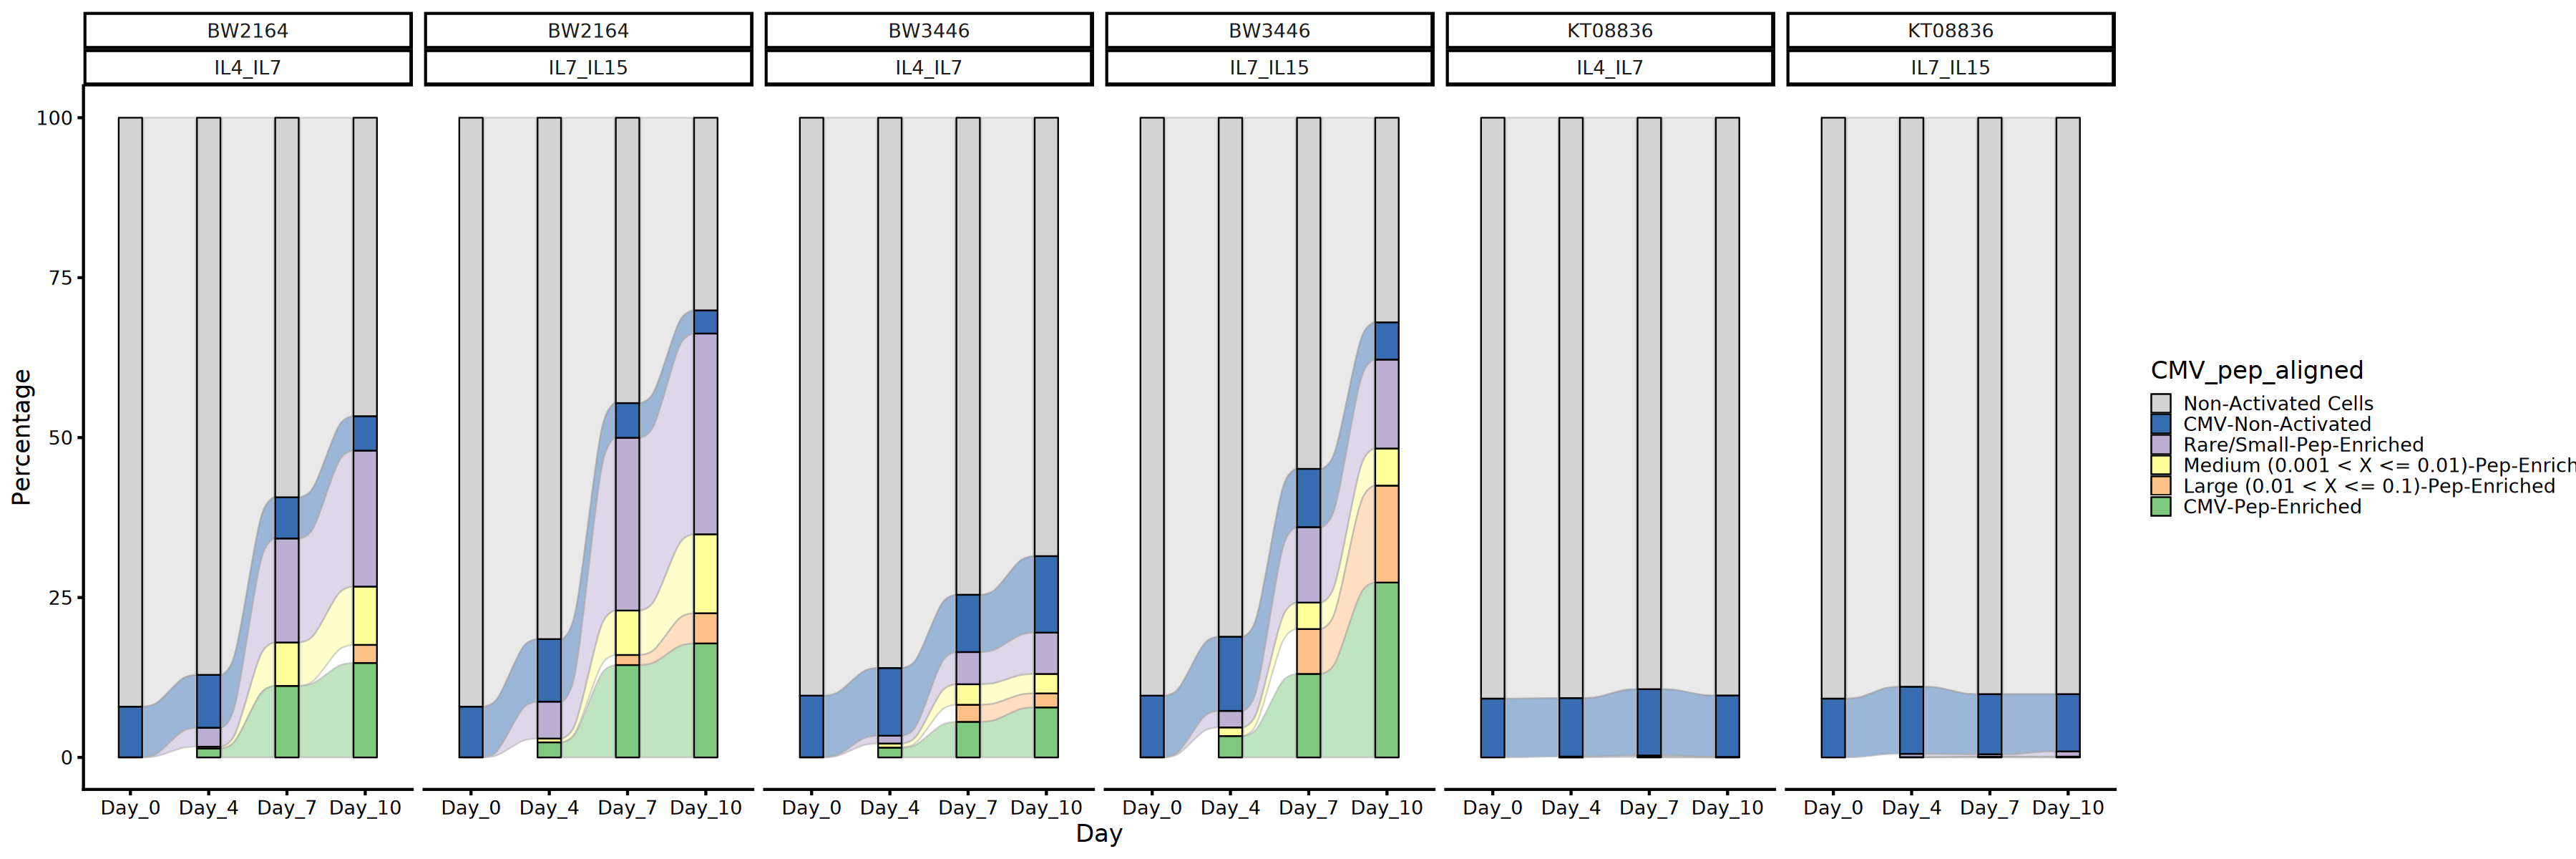

In [69]:
options(repr.plot.width = 30, repr.plot.height = 10)
cmv_summary_df_augmented %>%
    filter(Peptide == 'Pep+') %>%
    mutate(CMV_pep_aligned = factor(CMV_pep_aligned, 
                                    levels = c("Non-Activated Cells","CMV-Non-Activated",
                                               "Rare/Small-Pep-Enriched","Medium (0.001 < X <= 0.01)-Pep-Enriched","Large (0.01 < X <= 0.1)-Pep-Enriched","CMV-Pep-Enriched"))) %>%
    # filter(Day != 'Day_0') %>%
    # mutate(pep_enriched = factor(pep_enriched,
    #                              levels = c('Pep-Enriched','Non-Activated'))) %>%
    ggplot(aes(x = Day,
               y = percentage,
               stratum = CMV_pep_aligned,
               alluvium = CMV_pep_aligned,
               fill = CMV_pep_aligned,
               label = CMV_pep_aligned)) +
      geom_flow(stat = "alluvium", lode.guidance = "forward", color = "darkgray") +
      geom_stratum(width = 0.3, color = "black") +
      scale_fill_manual(values = c('lightgrey','#386CB0','#BEAED4','#FFFF99','#FDC086','#7FC97F')) +
      facet_grid(cols=vars(Donor,Culture)) +
      theme_classic(base_size = 20) +
      ylab("Percentage") + 
      # coord_cartesian(ylim = c(0, 60)) +
      theme(legend.position = "right")

In [70]:
# Open the PDF graphics device
pdf("plots/Fig2d_T_cell_CMV_mapping_pep_enriched_updated_vdjdb.pdf", width = 30, height = 10) # You can specify width and height in inches

# Create your plot
cmv_summary_df_augmented %>%
    filter(Peptide == 'Pep+') %>%
    mutate(CMV_pep_aligned = factor(CMV_pep_aligned, 
                                    levels = c("Non-Activated Cells","CMV-Non-Activated",
                                               "Rare/Small-Pep-Enriched","Medium (0.001 < X <= 0.01)-Pep-Enriched","Large (0.01 < X <= 0.1)-Pep-Enriched","CMV-Pep-Enriched"))) %>%
    # filter(Day != 'Day_0') %>%
    # mutate(pep_enriched = factor(pep_enriched,
    #                              levels = c('Pep-Enriched','Non-Activated'))) %>%
    ggplot(aes(x = Day,
               y = percentage,
               stratum = CMV_pep_aligned,
               alluvium = CMV_pep_aligned,
               fill = CMV_pep_aligned,
               label = CMV_pep_aligned)) +
      geom_flow(stat = "alluvium", lode.guidance = "forward", color = "darkgray") +
      geom_stratum(width = 0.3, color = "black") +
      scale_fill_manual(values = c('lightgrey','#386CB0','#BEAED4','#FFFF99','#FDC086','#7FC97F')) +
      facet_grid(cols=vars(Donor,Culture)) +
      theme_classic(base_size = 20) +
      ylab("Percentage") + 
      # coord_cartesian(ylim = c(0, 60)) +
      theme(legend.position = "right")

# Close the graphics device to save the plot
dev.off()

pdf 
  2

In [66]:
meta %>% 
    filter(pep_enriched == 'Pep-Enriched') %>%
    filter(Peptide == 'Pep+') %>%
    group_by(CMV_pep_aligned) %>%
    summarise(unique_CTaa = n_distinct(CTaa))

CMV_pep_aligned,unique_CTaa
<chr>,<int>
CMV-Pep-Enriched,4030
Large (0.01 < X <= 0.1)-Pep-Enriched,11
Medium (0.001 < X <= 0.01)-Pep-Enriched,129
Rare/Small-Pep-Enriched,13201
